# Optimal CCN diameter from the susceptibility plateau, validated against the weighted activation diameter

**Scientific question.** At each global grid cell, the CCN–CDNC susceptibility
$\beta(D)$ rises with the CCN cutoff diameter $D$ and then plateaus: beyond a
certain size, adding larger particles no longer increases the susceptibility.
The diameter at which that plateau begins — the **plateau edge** — is a natural
"optimal" CCN diameter for predicting CDNC. Does this purely susceptibility-derived
diameter agree with the physically-derived **weighted activation diameter**
(`Dact_weighted`, the NCONC-weighted bulk activation size computed from the
lognormal mode parameters)?

**Approach.**

1. For every grid cell, detect the plateau edge of the all-levels susceptibility
   profile $\beta(D)$ using a smoothed-gradient method (`find_plateau_edge`).
2. Map that optimal diameter globally and summarise its distribution.
3. Validate against `Dact_weighted`: for each cell, ask where the plateau edge
   falls within that cell's activation-diameter distribution (percentile rank),
   and whether the edge tracks the cell's **median** or **mean** activation
   diameter (paired Wilcoxon, log–log correlation).

A percentile rank near 50% and a closer match to the median than the mean would
indicate the susceptibility plateau edge is effectively picking out the typical
activation size of the aerosol population.

## 1 · Setup and data

`susceptibility_all_levels.nc` holds the all-levels susceptibility slope on a
`(lat, lon, radius, updraft_q)` grid; we take the `'Total'` updraft selection.
`Dact_weighted.nc` holds the weighted activation diameter on `(time, lev, lat,
lon)`.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
SUSC_DIR = Path("/share/pech2273/susceptibility")
ACT_DIR  = Path("/share/pech2273")

GRAD_SIGMA     = 1.5    # gaussian smoothing width for the gradient
DROP_THRESHOLD = 0.05   # normalised gradient below -this marks the plateau edge
DACT_FLOOR     = 1.0    # drop sub-nm activation-diameter tail [nm]

ds_alllevels = xr.open_dataset(SUSC_DIR / "susceptibility_all_levels.nc")
ds_actD      = xr.open_dataset(ACT_DIR / "Dact_weighted.nc")
ds_actD

<xarray.Dataset> Size: 6GB
Dimensions:        (lat: 96, lon: 144, lev: 10, time: 11689)
Coordinates:
  * lat            (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon            (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lev            (lev) float64 80B 691.4 763.4 820.9 ... 957.5 976.3 992.6
  * time           (time) datetime64[ns] 94kB 2011-01-01 ... 2015-01-01
Data variables:
    Dact_weighted  (time, lev, lat, lon) float32 6GB ...

## 2 · Plateau-edge optimal diameter per grid cell

`find_plateau_edge` smooths the susceptibility-vs-diameter profile, takes its
gradient, normalises by the profile range, and returns the diameter just before
the gradient first drops below `-DROP_THRESHOLD` — i.e. where the rise flattens.
A flat profile returns NaN; a profile that never declines returns the largest
diameter.

In [2]:
def find_plateau_edge(profile, diameter, sigma=GRAD_SIGMA,
                      drop_threshold=DROP_THRESHOLD):
    """Diameter at which a susceptibility profile stops rising (plateau edge).

    Parameters
    ----------
    profile : array-like
        Susceptibility as a function of diameter, one grid cell.
    diameter : array-like
        Diameter axis [nm], same length as ``profile``.
    sigma : float
        Gaussian smoothing width (in samples) applied before differentiating.
    drop_threshold : float
        The plateau edge is the last sample before the range-normalised
        gradient first falls below ``-drop_threshold``.

    Returns
    -------
    float
        Plateau-edge diameter [nm], or NaN for a flat profile.
    """
    smooth = gaussian_filter1d(profile, sigma=sigma)
    gradient = np.gradient(smooth)
    profile_range = smooth.max() - smooth.min()
    if profile_range == 0:
        return np.nan
    norm_gradient = gradient / profile_range
    decline = np.where(norm_gradient < -drop_threshold)[0]
    if len(decline) == 0:
        return diameter[-1]          # never declines -> largest diameter
    edge_idx = max(0, decline[0] - 1)
    return diameter[edge_idx]

In [3]:
# All-levels susceptibility, Total updraft selection -> (lat, lon, radius)
data = ds_alllevels.slope.sel(updraft_q="Total")
lat = data.lat.values
lon = data.lon.values
radius = data.radius.values
diameter = radius * 2.0                       # nm

# Flatten to (n_gridpoints, n_radius); drop cells with any NaN across radius
vals = data.values.reshape(-1, len(radius))   # (96*144, n_radius)
valid_mask = ~np.any(np.isnan(vals), axis=1)
vals_valid = vals[valid_mask]

# Plateau edge per valid cell, then scatter back onto the full grid
optimal_valid = np.array([
    find_plateau_edge(vals_valid[k], diameter) for k in range(len(vals_valid))
])
optimal_full = np.full(valid_mask.shape, np.nan)
optimal_full[valid_mask] = optimal_valid
optimal_diameters_2d = optimal_full.reshape(len(lat), len(lon))

print(f"Optimal (plateau-edge) diameter — valid cells: {valid_mask.sum()}")
print(f"  min={np.nanmin(optimal_diameters_2d):.1f}  "
      f"max={np.nanmax(optimal_diameters_2d):.1f}  "
      f"mean={np.nanmean(optimal_diameters_2d):.1f}  "
      f"median={np.nanmedian(optimal_diameters_2d):.1f} nm")

Optimal (plateau-edge) diameter — valid cells: 13264
  min=5.1  max=1002.4  mean=115.6  median=113.8 nm


### Figure 1 — Global map of the optimal CCN diameter

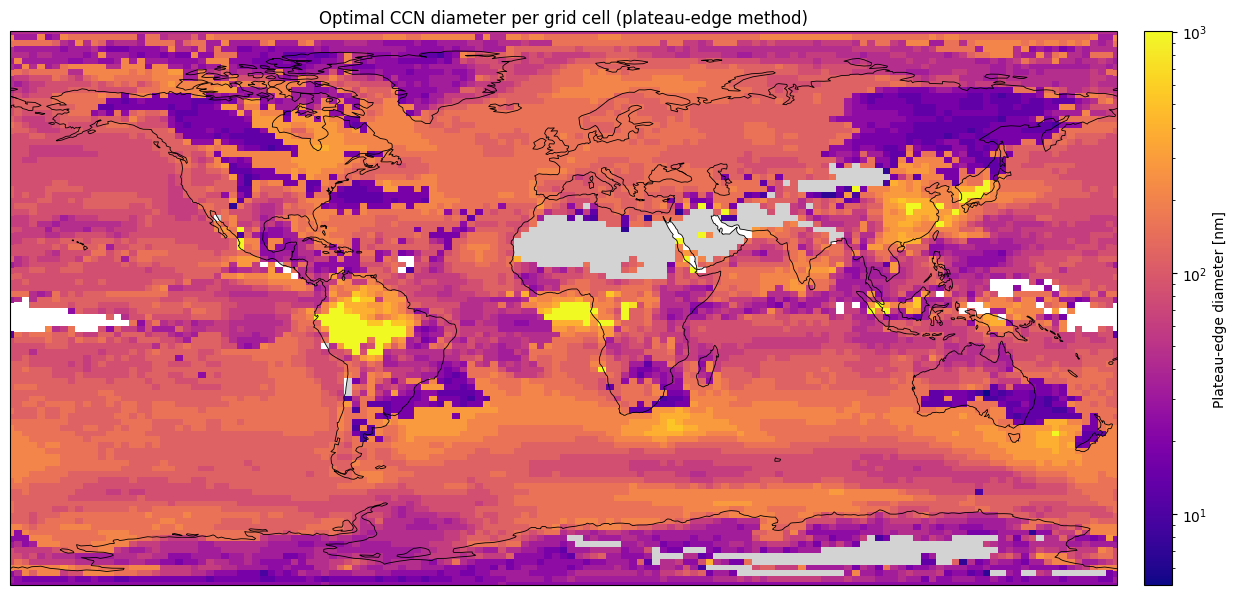

In [4]:
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
cmap = plt.cm.plasma.copy()
cmap.set_bad(alpha=0)
im = ax.pcolormesh(
    lon, lat, np.ma.masked_invalid(optimal_diameters_2d), cmap=cmap,
    norm=mpl.colors.LogNorm(vmin=np.nanmin(optimal_diameters_2d),
                            vmax=np.nanmax(optimal_diameters_2d)),
    transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
cb = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02)
cb.set_label("Plateau-edge diameter [nm]")
ax.set_title("Optimal CCN diameter per grid cell (plateau-edge method)")
fig.tight_layout()
plt.show()

### Figure 2 — Distribution of optimal diameters

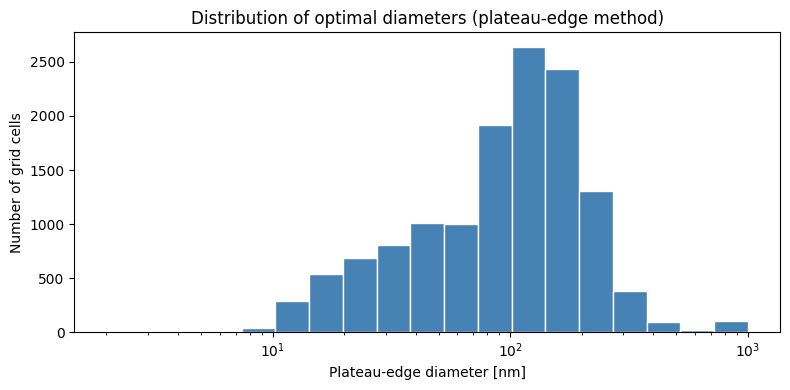

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)
ax.hist(optimal_valid, bins=log_bins, color="steelblue", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Plateau-edge diameter [nm]")
ax.set_ylabel("Number of grid cells")
ax.set_title("Distribution of optimal diameters (plateau-edge method)")
fig.tight_layout()
plt.show()

## 3 · Validation against the weighted activation diameter

Load `Dact_weighted` and pool over time and level (matching the all-levels
plateau edge). We keep three views of each cell's activation-diameter
distribution: the full pooled sample (for percentile rank), and the per-cell
mean and median (for the paired comparison). The sub-nm tail is dropped with
`DACT_FLOOR`.

In [6]:
dact = ds_actD["Dact_weighted"].where(ds_actD["Dact_weighted"] >= DACT_FLOOR)

# Pool over whatever sampling dims are present (time and/or lev)
sample_dims = [d for d in ("time", "lev") if d in dact.dims]

dact_mean   = dact.mean(dim=sample_dims, skipna=True).transpose("lat", "lon").values
dact_median = dact.median(dim=sample_dims, skipna=True).transpose("lat", "lon").values

# Collapse sampling dims into ONE axis -> (sample, lat, lon)
dact_stack = dact.stack(sample=sample_dims).transpose("sample", "lat", "lon")
dvals = dact_stack.values

edge = optimal_diameters_2d                  # (lat, lon)

# Grid-alignment guards: same shape and same coordinates as the edge map
assert dvals.shape[1:] == edge.shape, (dvals.shape, edge.shape)
np.testing.assert_allclose(dact_stack.lat.values, lat)
np.testing.assert_allclose(dact_stack.lon.values, lon)

### Per-cell percentile rank of the plateau edge

For each cell, what fraction of that cell's activation-diameter samples fall at
or below the plateau edge? A rank near 50% means the edge sits at the cell's
median activation diameter.

In [7]:
nlat, nlon = edge.shape
pct_rank = np.full((nlat, nlon), np.nan)
for i in range(nlat):
    for j in range(nlon):
        e = edge[i, j]
        col = dvals[:, i, j]
        col = col[np.isfinite(col)]
        if np.isfinite(e) and col.size > 5:
            pct_rank[i, j] = 100.0 * np.mean(col <= e)

pr = pct_rank[np.isfinite(pct_rank)]
print("Percentile rank of plateau edge within each cell's Dact distribution:")
print(f"  n cells     = {pr.size}")
print(f"  median rank = {np.median(pr):.1f}%    mean rank = {pr.mean():.1f}%")
print(f"  fraction with edge in 25-75th pct of Dact: "
      f"{np.mean((pr >= 25) & (pr <= 75)):.1%}")

Percentile rank of plateau edge within each cell's Dact distribution:
  n cells     = 13264
  median rank = 53.0%    mean rank = 50.6%
  fraction with edge in 25-75th pct of Dact: 26.5%


### Paired comparison: edge vs per-cell mean and median

Across all cells with finite edge, mean, and median, compare the plateau edge to
each reference with a paired Wilcoxon test and a log–log correlation, and count
how often the edge is closer to the cell's median than its mean.

In [8]:
m = np.isfinite(edge) & np.isfinite(dact_mean) & np.isfinite(dact_median)
e, dmu, dmd = edge[m], dact_mean[m], dact_median[m]

print(f"Paired comparison across {e.size} cells:")
for name, ref in [("per-cell MEAN", dmu), ("per-cell MEDIAN", dmd)]:
    d = e - ref
    w = stats.wilcoxon(d)
    r = np.corrcoef(np.log(e), np.log(ref))[0, 1]
    print(f"\nEdge vs {name}:")
    print(f"  median(edge - ref) = {np.median(d):+.2f} nm")
    print(f"  mean  (edge - ref) = {d.mean():+.2f} nm")
    print(f"  Wilcoxon: W={w.statistic:.0f}, p={w.pvalue:.3g}")
    print(f"  log-log Pearson r = {r:.3f}")

closer_to_median = np.abs(e - dmd) < np.abs(e - dmu)
print(f"\nEdge is closer to the cell's MEDIAN than its MEAN in "
      f"{np.mean(closer_to_median):.1%} of cells.")

Paired comparison across 13264 cells:

Edge vs per-cell MEAN:
  median(edge - ref) = +0.40 nm
  mean  (edge - ref) = +16.36 nm
  Wilcoxon: W=39155760, p=6.33e-28
  log-log Pearson r = 0.300

Edge vs per-cell MEDIAN:
  median(edge - ref) = +2.22 nm
  mean  (edge - ref) = +18.50 nm
  Wilcoxon: W=37762903, p=3.17e-45
  log-log Pearson r = 0.309

Edge is closer to the cell's MEDIAN than its MEAN in 57.0% of cells.


### Figure 3 — Map of percentile rank

Blue/red around 50% (white) indicates the plateau edge tracks the cell's median
activation diameter; saturated colours mark cells where the edge sits in the
tails of the activation-diameter distribution.

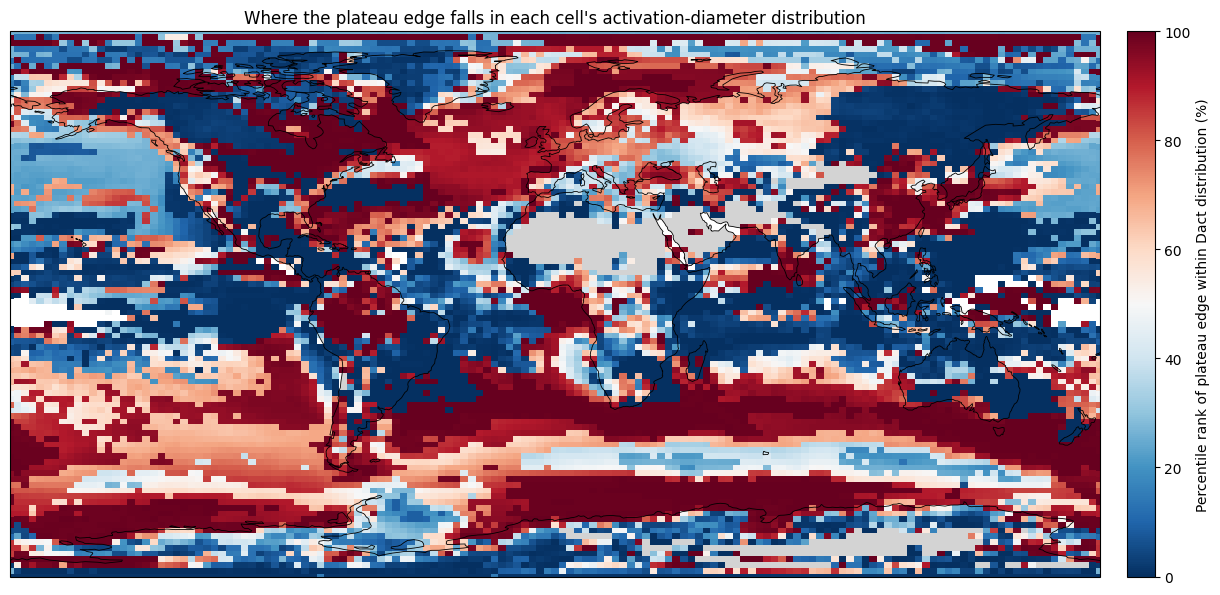

In [9]:
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(lon, lat, np.ma.masked_invalid(pct_rank),
                   cmap="RdBu_r", vmin=0, vmax=100,
                   transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Percentile rank of plateau edge within Dact distribution (%)")
ax.set_title("Where the plateau edge falls in each cell's "
             "activation-diameter distribution")
fig.tight_layout()
plt.show()

### Figure 4 — Median activation diameter map (reference)

The per-cell median `Dact` for context alongside the rank map above.

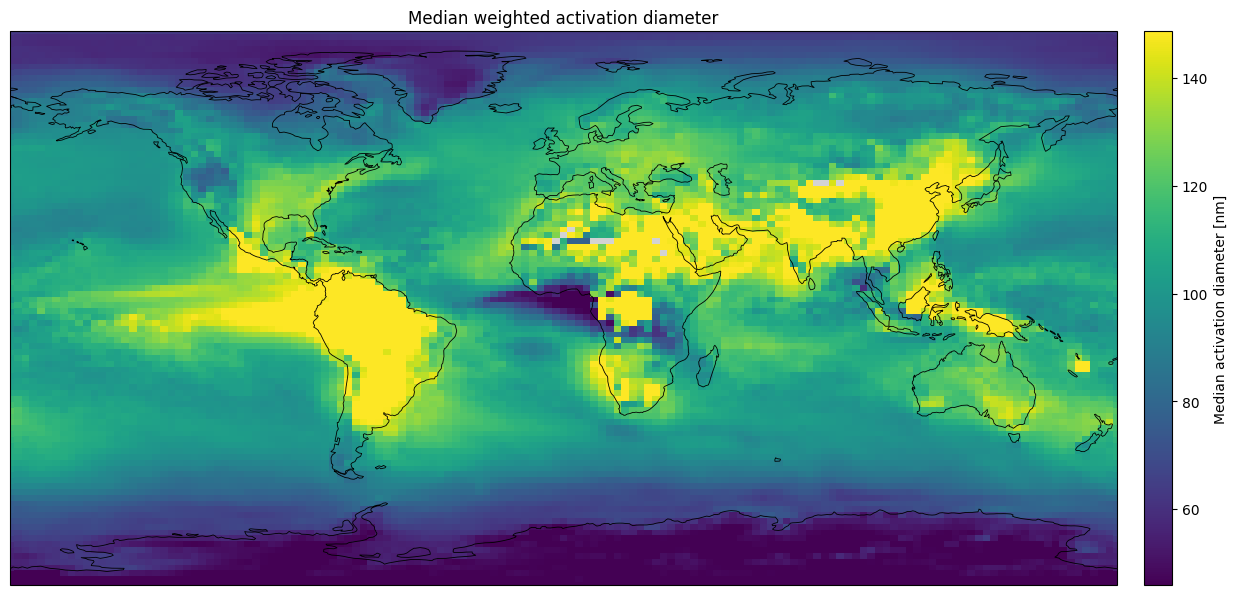

In [10]:
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(
    lon, lat, np.ma.masked_invalid(dact_median), cmap="viridis",
    vmin=np.nanquantile(dact_median, 0.05),
    vmax=np.nanquantile(dact_median, 0.95),
    transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Median activation diameter [nm]")
ax.set_title("Median weighted activation diameter")
fig.tight_layout()
plt.show()

### Figure 5 — Optimal diameter vs median activation diameter

Direct overlay of the two diameter distributions on shared log bins: the
plateau-edge optimal diameter and the per-cell median activation diameter.

In [18]:
dact_median.flatten()

array([40.736855, 40.685436, 40.72838 , ..., 62.785408, 62.97554 ,
       62.9061  ], shape=(13824,), dtype=float32)

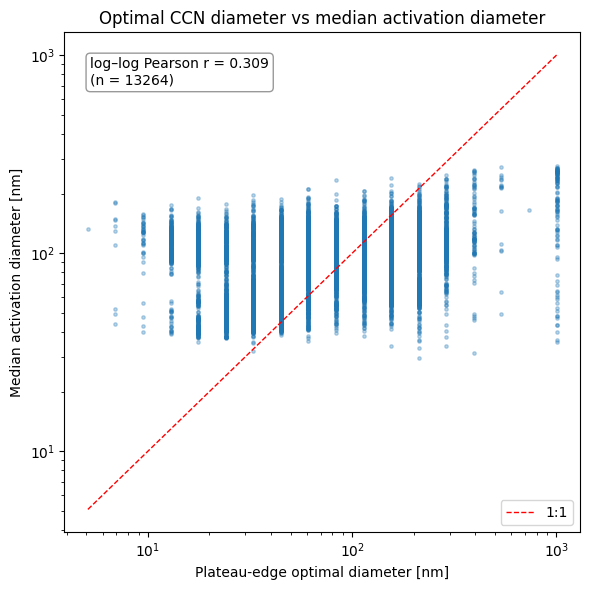

In [21]:
edge_flat = optimal_diameters_2d.flatten()   # full grid, NaN where invalid
dmd_flat  = dact_median.flatten()            # full grid

m = np.isfinite(edge_flat) & np.isfinite(dmd_flat)
x, y = edge_flat[m], dmd_flat[m]

# Pearson r in log space (matches the log axes and the wide diameter range)
r_log, p_log = stats.pearsonr(np.log(x), np.log(y))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=6, alpha=0.3)
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
ax.plot(lims, lims, "--", color="red", lw=1, label="1:1")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Plateau-edge optimal diameter [nm]")
ax.set_ylabel("Median activation diameter [nm]")
ax.set_title("Optimal CCN diameter vs median activation diameter")
ax.text(0.05, 0.95, f"log–log Pearson r = {r_log:.3f}\n(n = {x.size})",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

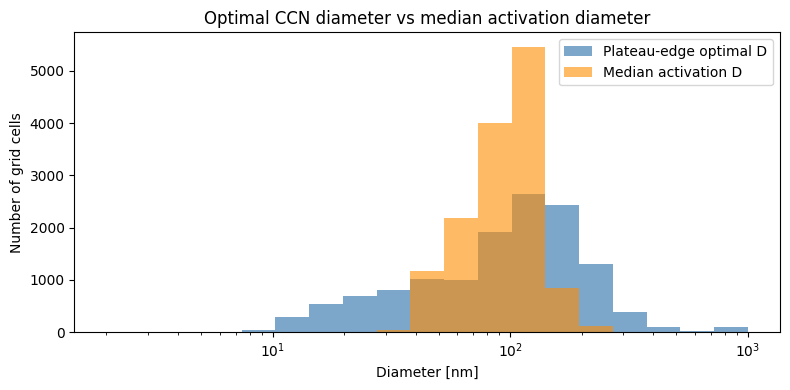

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)
ax.hist(optimal_valid, bins=log_bins, color="steelblue", alpha=0.7,
        label="Plateau-edge optimal D")
ax.hist(dact_median[np.isfinite(dact_median)], bins=log_bins,
        color="darkorange", alpha=0.6, label="Median activation D")
ax.set_xscale("log")
ax.set_xlabel("Diameter [nm]")
ax.set_ylabel("Number of grid cells")
ax.set_title("Optimal CCN diameter vs median activation diameter")
ax.legend()
fig.tight_layout()
plt.show()